In [1]:
# Sinogrammer

import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import pandas as pd
from matplotlib.gridspec import GridSpec

In [74]:
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]
print(map[0:5])
def lor_to_sinogram_coords(x1, y1, x2, y2):
    dx, dy = x2 - x1, y2 - y1
    nx, ny = -dy, dx
    norm = np.hypot(nx, ny)
    nx /= norm
    ny /= norm
    theta = np.arctan2(ny, nx)
    s = x1 * nx + y1 * ny
    if theta < 0:
        theta += np.pi
        s = -s
    elif theta >= np.pi:
        theta -= np.pi
        s = -s
    return theta, s

n_theta, n_s = 200, 200
theta_min, theta_max = 0, 180
s_max = 150
def make_sinogram(eventcounts, map = map, n_theta=n_theta, n_s=n_s, theta_min=theta_min, theta_max=theta_max, s_max=s_max):
    theta_edges = np.linspace(theta_min * np.pi / 180, theta_max * np.pi / 180, n_theta + 1)
    s_edges = np.linspace(-s_max, s_max, n_s + 1)
    sinogram = np.zeros((n_theta, n_s), dtype=np.float32)
    for i in tqdm(range(3072)):
        for j in range(3072):
            if eventcounts[i, j] == 0:
                continue
            x1, y1 = map[i + 3072, 0], map[i + 3072, 1]
            x2, y2 = map[j, 0], map[j, 1]
            t, s = lor_to_sinogram_coords(x1, y1, x2, y2)
            itheta = np.searchsorted(theta_edges, t, side='right') - 1
            is_ = np.searchsorted(s_edges, s, side='right') - 1
            if (0 <= itheta < n_theta) and (0 <= is_ < n_s):
                sinogram[itheta, is_] += eventcounts[i, j]

    return sinogram, theta_edges, s_edges
def sinogram_heatmap_nice(data, fig_num, cmap='hot', name = 'Sinogram'):
    fig = plt.figure(fig_num, figsize=(5, 4.5))
    gs = GridSpec(1, 2, width_ratios=[9, 1], hspace=0, wspace=0)
    axhm = fig.add_subplot(gs[0, 0])
    axcbar = fig.add_subplot(gs[0, 1])
    hm = axhm.imshow(data, cmap=cmap, aspect='auto', extent=[-s_max, s_max, 0, 180])
    axhm.set_xticks(np.linspace(-s_max, s_max, 5))
    axhm.set_yticks(np.linspace(0, 180, 5))
    axhm.set_xlabel('Radius (mm)')
    axhm.set_ylabel('Angle (deg)')
    axhm.set_title(name)
    cbar = fig.colorbar(hm, cax=axcbar)
    cbar.set_ticks(np.linspace(np.nanmin(data), np.nanmax(data), 5))
    cbar.set_ticklabels([f"{tick:.2e}" for tick in np.linspace(np.nanmin(data), np.nanmax(data), 5)]) 
    axhm.grid(True, color = 'white', linewidth = 0.5)
    return hm

[[ 117.3250734 -120.1245968   38.       ]
 [ 114.8917743 -122.2028306   38.       ]
 [ 112.4584752 -124.2810643   28.4      ]
 [ 117.3250734 -120.1245968   34.8      ]
 [ 110.0251761 -126.3592981   34.8      ]]


In [19]:
path1 = f'/home/kale-chen/Documents/PET/TPPT2026/data/pR6.bin'
path2 = '/home/kale-chen/Documents/PET/TPPT2026/data/pR1.bin'
num_cols1, num_cols2, data_size = 4,  4, 2
num_rows1 = os.path.getsize(path1) // (num_cols1 * data_size)
data1 = np.memmap(path1, dtype = np.int16, mode = 'r', shape = (num_rows1, num_cols1))
eventcounts1 = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows1, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    if num_cols1 == 3 or num_cols1 == 2 or num_cols1 == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols1 == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(eventcounts1, (idls, idrs), 1)
num_rows2 = os.path.getsize(path2) // (num_cols2 * data_size)
data2 = np.memmap(path2, dtype = np.int16, mode = 'r', shape = (num_rows2, num_cols2))
eventcounts2 = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows2, 1000000), desc='Event counts'):
    chunk = data2[i:i+1000000]
    if num_cols2 == 3 or num_cols2 == 2 or num_cols2 == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols2 == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(eventcounts2, (idls, idrs), 1)
sinogram1, theta_edges1, s_edges1 = make_sinogram(eventcounts1)
sinogram2, theta_edges2, s_edges2 = make_sinogram(eventcounts2)

100%|██████████| 3072/3072 [00:36<00:00, 84.85it/s]


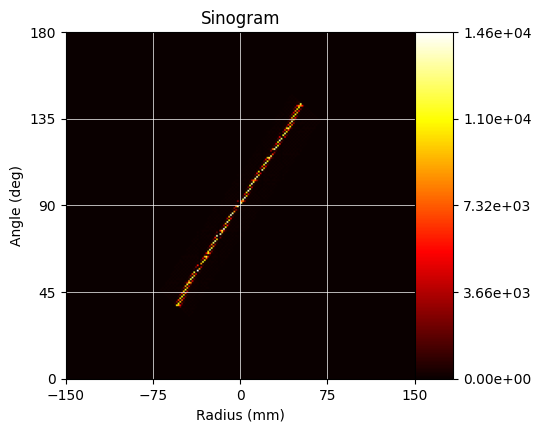

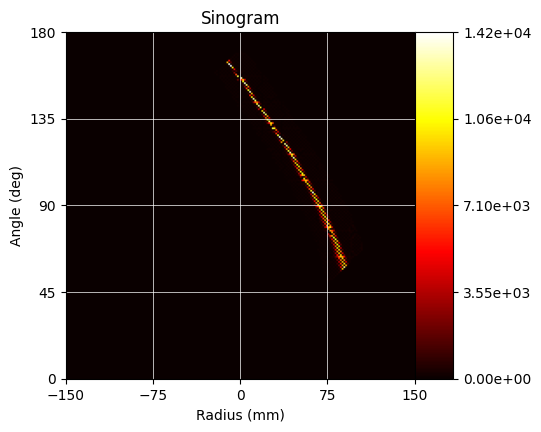

In [10]:
sinogram_heatmap_nice(sinogram1, 1)
sinogram_heatmap_nice(sinogram2, 2)
plt.show()

(180, 180)


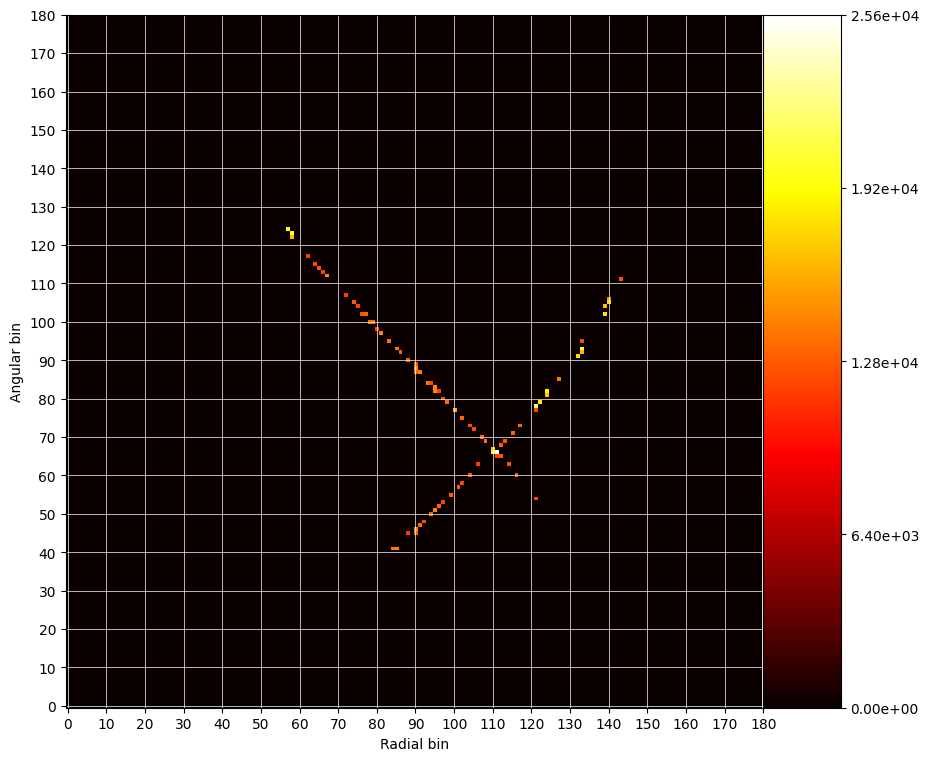

In [28]:
fig = plt.figure(0, figsize=(10, 9))
gs = GridSpec(1, 2, width_ratios=[9, 1], hspace=0, wspace=0)
axhm = fig.add_subplot(gs[0, 0])
axcbar = fig.add_subplot(gs[0, 1])
combined_sinogram = sinogram1 + sinogram2
print(combined_sinogram.shape)
combined_sinogram[combined_sinogram < 1.15e4] = 0
hm1 = axhm.imshow(combined_sinogram, cmap='hot', aspect='auto', origin='lower')
axhm.set_xticks(np.linspace(0, 180, 19))
axhm.set_yticks(np.linspace(0, 180, 19))
axhm.set_xlabel('Radial bin')
axhm.set_ylabel('Angular bin')
cbar = fig.colorbar(hm1, cax=axcbar)
cbar.set_ticks(np.linspace(np.nanmin(combined_sinogram), np.nanmax(combined_sinogram), 5))
cbar.set_ticklabels([f"{tick:.2e}" for tick in np.linspace(np.nanmin(combined_sinogram), np.nanmax(combined_sinogram), 5)]) 
axhm.grid(True, color = 'white', linewidth = 0.5)
plt.show()

In [66]:
path1 = f'/home/kale-chen/Documents/PET/TPPT2026/data/pointsR.bin'
num_cols1, num_cols2, data_size = 6,  4, 2
num_rows1 = os.path.getsize(path1) // (num_cols1 * data_size)
data1 = np.memmap(path1, dtype = np.int16, mode = 'r', shape = (num_rows1, num_cols1))
eventcounts1 = np.zeros((3072, 3072), dtype = np.float32)
strides = [30000, 10000]
for i in tqdm(range(0, num_rows1, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    if chunk[0, 5] > 60 and chunk[0, 5] < 120:
        chunk = chunk[::strides[0]]
    elif chunk[0, 5] > 360 and chunk[0, 5] < 420:
        chunk = chunk[::strides[0]]
    else:
        chunk = chunk[::strides[1]]
    if num_cols1 == 3 or num_cols1 == 2 or num_cols1 == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols1 == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(eventcounts1, (idls, idrs), 1)
sinogram, theta_edges1, s_edges1 = make_sinogram(eventcounts1)

100%|██████████| 3072/3072 [00:00<00:00, 3433.67it/s]


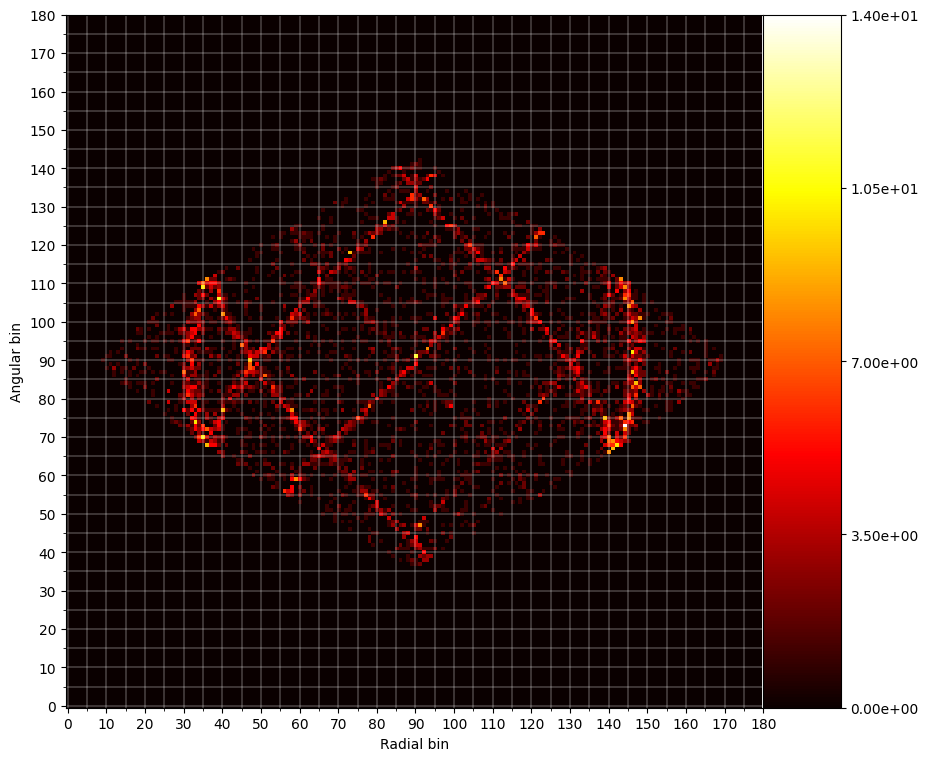

In [70]:
fig = plt.figure(0, figsize=(10, 9))
gs = GridSpec(1, 2, width_ratios=[9, 1], hspace=0, wspace=0)
axhm = fig.add_subplot(gs[0, 0])
axcbar = fig.add_subplot(gs[0, 1])
#sinogram[sinogram < 3] = 0
hm1 = axhm.imshow(sinogram, cmap='hot', aspect='auto', origin='lower')
axhm.set_xticks(np.linspace(0, 180, 19))
axhm.set_yticks(np.linspace(0, 180, 19))
# Add minor ticks at half lengths
axhm.set_xticks(np.linspace(0, 180, 37), minor=True)
axhm.set_yticks(np.linspace(0, 180, 37), minor=True)
axhm.set_xlabel('Radial bin')
axhm.set_ylabel('Angular bin')
cbar = fig.colorbar(hm1, cax=axcbar)
cbar.set_ticks(np.linspace(np.nanmin(sinogram), np.nanmax(sinogram), 5))
cbar.set_ticklabels([f"{tick:.2e}" for tick in np.linspace(np.nanmin(sinogram), np.nanmax(sinogram), 5)]) 
axhm.grid(True, color = 'white', linewidth = 0.3, which='both')
plt.show()

In [104]:
path1 = f'/home/kale-chen/Documents/PET/TPPT2026/data/hcircpgd.bin'
num_cols1, num_cols2, data_size = 4,  4, 2
num_rows1 = os.path.getsize(path1) // (num_cols1 * data_size)
data1 = np.memmap(path1, dtype = np.int16, mode = 'r', shape = (num_rows1, num_cols1))
eventcounts1 = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows1, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000:10]
    if num_cols1 == 3 or num_cols1 == 2 or num_cols1 == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols1 == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(eventcounts1, (idls, idrs), 1)
eventcounts1[1024:1408] = 0
eventcounts1[1920:2048] = 0
eventcounts1[:,1024:1408] = 0
sinogram, theta_edges1, s_edges1 = make_sinogram(eventcounts1)

100%|██████████| 3072/3072 [00:05<00:00, 515.99it/s] 


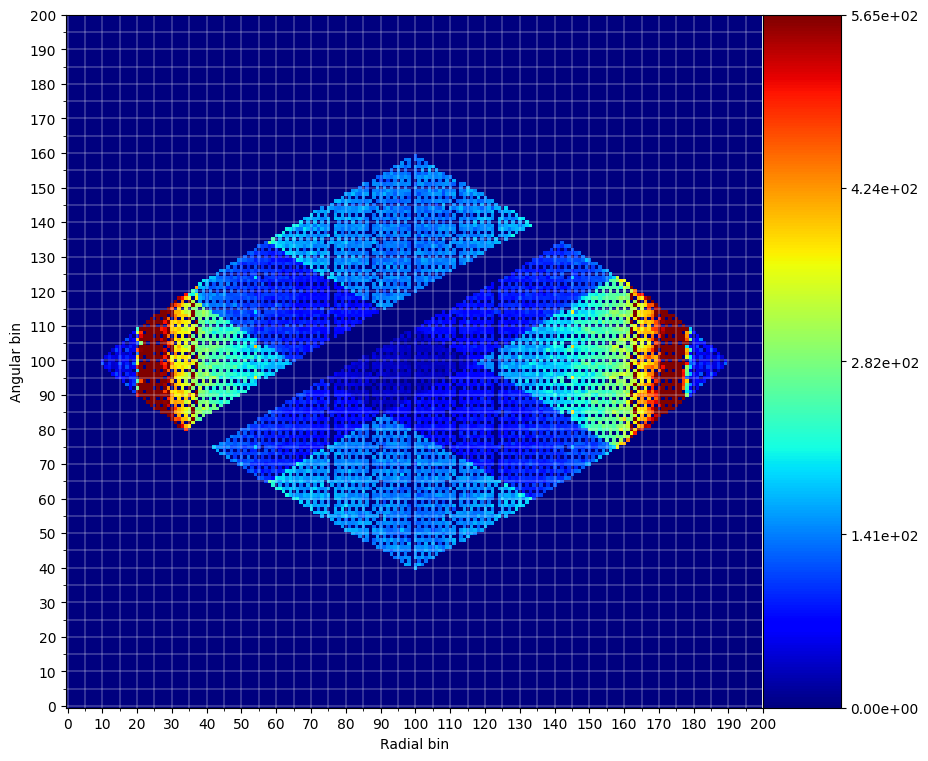

In [106]:
fig = plt.figure(0, figsize=(10, 9))
gs = GridSpec(1, 2, width_ratios=[9, 1], hspace=0, wspace=0)
axhm = fig.add_subplot(gs[0, 0])
axcbar = fig.add_subplot(gs[0, 1])
div = 4
hm1 = axhm.imshow(sinogram, cmap='jet', aspect='auto', origin='lower', vmin = 0, vmax = np.max(sinogram) / div)
axhm.set_xticks(np.linspace(0, 200, 21))
axhm.set_yticks(np.linspace(0, 200, 21))
# Add minor ticks at half lengths
axhm.set_xticks(np.linspace(0, 200, 41), minor=True)
axhm.set_yticks(np.linspace(0, 200, 41), minor=True)
axhm.set_xlabel('Radial bin')
axhm.set_ylabel('Angular bin')
cbar = fig.colorbar(hm1, cax=axcbar)
cbar.set_ticks(np.linspace(np.nanmin(sinogram), np.nanmax(sinogram) / div, 5))
cbar.set_ticklabels([f"{tick:.2e}" for tick in np.linspace(np.nanmin(sinogram), np.nanmax(sinogram) / div, 5)]) 
axhm.grid(True, color = 'white', linewidth = 0.3, which='both')
plt.show()

In [121]:
path1 = f'/home/kale-chen/Documents/PET/TPPT2026/data/hcircpgd.bin'
num_cols1, num_cols2, data_size = 4,  4, 2
num_rows1 = os.path.getsize(path1) // (num_cols1 * data_size)
data1 = np.memmap(path1, dtype = np.int16, mode = 'r', shape = (num_rows1, num_cols1))
eventcounts1 = np.zeros((3072, 3072), dtype = np.float32)
times = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows1, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000:1000]
    if num_cols1 == 3 or num_cols1 == 2 or num_cols1 == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols1 == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(eventcounts1, (idls, idrs), 1)
    np.add.at(times, (idls, idrs), chunk[:, 3])
eventcounts1[eventcounts1 == 0] = 1
times = times / eventcounts1
sinogram, theta_edges1, s_edges1 = make_sinogram(times)
print(np.max(sinogram), np.min(sinogram))

100%|██████████| 3072/3072 [00:00<00:00, 3217.32it/s]

10368.0 0.0


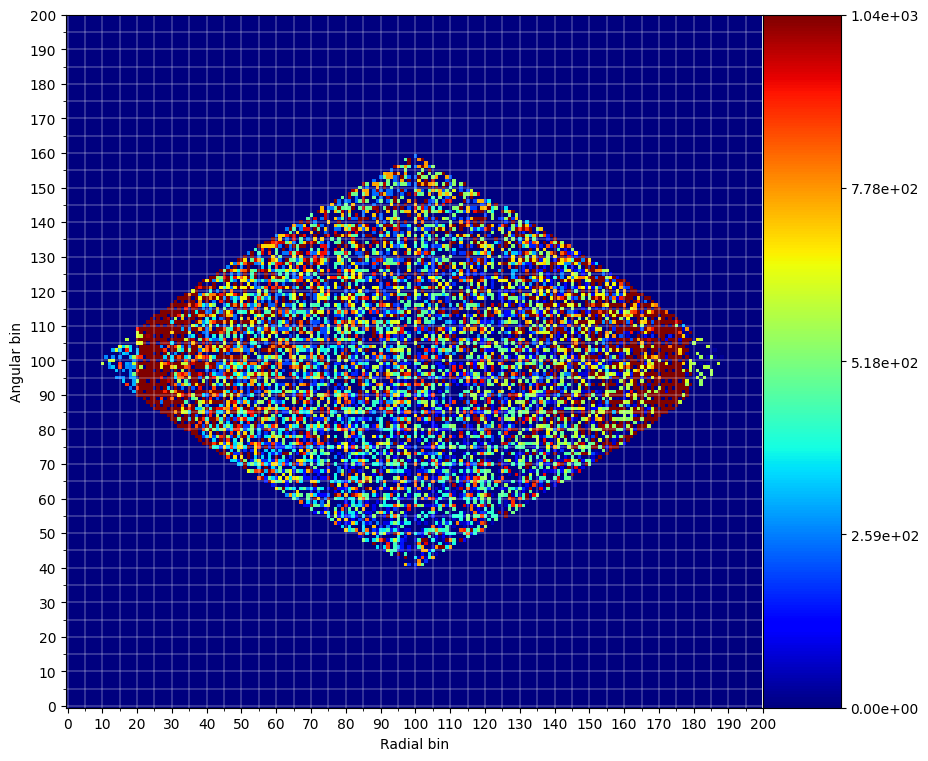

In [122]:
fig = plt.figure(0, figsize=(10, 9))
gs = GridSpec(1, 2, width_ratios=[9, 1], hspace=0, wspace=0)
axhm = fig.add_subplot(gs[0, 0])
axcbar = fig.add_subplot(gs[0, 1])
div = 10
hm1 = axhm.imshow(sinogram, cmap='jet', aspect='auto', origin='lower', vmin = 0, vmax = np.max(sinogram) / div)
axhm.set_xticks(np.linspace(0, 200, 21))
axhm.set_yticks(np.linspace(0, 200, 21))
# Add minor ticks at half lengths
axhm.set_xticks(np.linspace(0, 200, 41), minor=True)
axhm.set_yticks(np.linspace(0, 200, 41), minor=True)
axhm.set_xlabel('Radial bin')
axhm.set_ylabel('Angular bin')
cbar = fig.colorbar(hm1, cax=axcbar)
cbar.set_ticks(np.linspace(np.nanmin(sinogram), np.nanmax(sinogram) / div, 5))
cbar.set_ticklabels([f"{tick:.2e}" for tick in np.linspace(np.nanmin(sinogram), np.nanmax(sinogram) / div, 5)]) 
axhm.grid(True, color = 'white', linewidth = 0.3, which='both')
plt.show()